## Imports

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import BinaryEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder, BinaryEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import mutual_info_classif, chi2, f_classif, SelectKBest
from sklearn.metrics import roc_auc_score, classification_report
import pickle

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_regression, f_regression, SelectKBest
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN  # The Hybrid Method
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


## Data familiarization

In [162]:
df_orgin = pd.read_csv(r"./data/aqarmap_final.csv")
df = df_orgin.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4753 entries, 0 to 4752
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Listing_ID       4744 non-null   str    
 1   Type             4753 non-null   str    
 2   Address          4753 non-null   str    
 3   Price            4753 non-null   float64
 4   Price_Per_M2     4739 non-null   float64
 5   Area             4685 non-null   float64
 6   Rooms            4314 non-null   str    
 7   Bathrooms        4273 non-null   str    
 8   Floor            3853 non-null   float64
 9   Year_Built       4023 non-null   float64
 10  Finish           4753 non-null   int64  
 11  View             4702 non-null   str    
 12  Seller_Type      4282 non-null   str    
 13  Amenities        3230 non-null   str    
 14  Description      1248 non-null   str    
 15  Link             4753 non-null   str    
 16  Amenities_Count  4753 non-null   int64  
 17  Is_Installments  4753 non

In [163]:
df.head()

,Listing_ID,Type,Address,Price,Price_Per_M2,Area,Rooms,Bathrooms,Floor,Year_Built,Finish,View,Seller_Type,Amenities,Description,Link,Amenities_Count,Is_Installments
0,EG-6901132,Villa,north coast resorts riviera,"6,800,000.00","19,429.00",350.00,4 rooms,3 bathroom,NaN,"2,009.00",1,Garden,Developer,Garden,Villa For sale in Riviera,https://aqarmap.com.eg/en/listing/6901132-for-...,1,1
1,EG-6671452,Apartment,cairo 6th of october compounds murooj,"5,000,000.00","37,594.00",133.00,3 rooms,2 bathroom,2.00,"2,026.00",1,Main Street,Developer,NaN,Apartment For sale in Murooj Compound - Dar El...,https://aqarmap.com.eg/en/listing/6671452-for-...,0,0
2,EG-6903778,Land,cairo 6th of october ltws t lshrqy,"5,500,000.00","5,314.00","1,035.00",NaN,NaN,NaN,NaN,1,Main Street,Broker,NaN,Land For sale in Eastern Expansions with size ...,https://aqarmap.com.eg/en/listing/6903778-for-...,0,0
3,EG-6897924,Chalet,north coast resorts solare resort misr italia,"9,974,100.00","75,561.00",132.00,2 rooms,2 bathroom,0.00,"2,029.00",1,Lake,Private Owner,"Security, Garden, Solar",Directly from the ownerA ground-floor chalet w...,https://aqarmap.com.eg/en/listing/6897924-for-...,3,1
4,EG-6898957,Apartment,cairo new heliopolis lhy lthny,"1,600,000.00","13,333.00",120.00,2 rooms,3 bathroom,3.00,"2,025.00",1,Main Street,Developer,NaN,Apartments For sale with size 120 M² Semi Fini...,https://aqarmap.com.eg/en/listing/6898957-for-...,0,1


In [164]:
df.describe()

,Price,Price_Per_M2,Area,Floor,Year_Built,Finish,Amenities_Count,Is_Installments
count,"4,753.00","4,739.00","4,685.00","3,853.00","4,023.00","4,753.00","4,753.00","4,753.00"
mean,"10,515,278.97","53,240.05",267.53,2.88,"2,021.49",0.99,2.13,0.46
std,"19,563,092.79","49,829.59","1,679.00",2.93,9.33,0.10,2.00,0.50
min,"3,500.00",20.00,0.00,0.00,"1,925.00",0.00,0.00,0.00
25%,"3,612,000.00","24,615.00",120.00,1.00,"2,020.00",1.00,0.00,0.00
50%,"6,000,000.00","37,267.00",160.00,2.00,"2,025.00",1.00,1.00,0.00
75%,"10,450,000.00","62,989.50",220.00,4.00,"2,026.00",1.00,4.00,1.00
max,"599,949,000.00","617,480.00","63,000.00",45.00,"2,037.00",1.00,7.00,1.00


# Data Tidying & Structural Analysis

In [165]:
df.isnull().sum()

Listing_ID            9
Type                  0
Address               0
Price                 0
Price_Per_M2         14
Area                 68
Rooms               439
Bathrooms           480
Floor               900
Year_Built          730
Finish                0
View                 51
Seller_Type         471
Amenities          1523
Description        3505
Link                  0
Amenities_Count       0
Is_Installments       0
dtype: int64

In [166]:
print(f"before duplicates: {df.shape[0]}")
df = df.drop_duplicates(subset=["Listing_ID"])
print(f"after duplicates: {df.shape[0]}")

before duplicates: 4753
after duplicates: 4725


In [167]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f"{col} unique_count: {df[col].nunique()}, \n top_values: {df[col].value_counts().head(10).to_dict()}")

Listing_ID unique_count: 4724, 
 top_values: {'EG-6901132': 1, 'EG-6671452': 1, 'EG-6903778': 1, 'EG-6897924': 1, 'EG-6898957': 1, 'EG-6859550': 1, 'EG-6899863': 1, 'EG-6723602': 1, 'EG-6816744': 1, 'EG-6547418': 1}
Type unique_count: 13, 
 top_values: {'Apartment': 2977, 'Duplex': 536, 'Villa': 416, 'Chalet': 181, 'Roof': 154, 'Penthouse': 146, 'Office': 76, 'Studio': 67, 'Commercial': 60, 'Land': 58}
Address unique_count: 1563, 
 top_values: {'red sea hurghada city el hadba sheraton st': 59, 'red sea hy lkwthr': 42, 'alexandria smouha Muruj': 39, 'cairo 6th of october el tawsaat el shamalya hy 2000 qt': 36, 'the med': 36, 'kite residence': 34, 'isola compound': 34, 'north coast resorts virginia plaza resort solid': 33, 'cairo 6th of october hadaeq october compounds sun capital': 31, 'cairo new cairo bait el watan fourth neighborhood': 30}
Rooms unique_count: 78, 
 top_values: {'3 rooms': 2131, '2 rooms': 867, '4 rooms': 408, '1 rooms': 338, '5 rooms': 130, '3': 62, '6 rooms': 54, '2'

C:\Users\amrta\AppData\Local\Temp\ipykernel_21684\1971780853.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


## Amenities column

The `Amenities` column is a raw comma-separated string (ex: `"Pool, Elevator, Security"`).
Instead of one-hot encoding each amenity (sparse + noisy), we group them into 4 semantic binary flags

In [168]:
df["Amenities"].value_counts()

Amenities
Garden                                                     737
Elevator, Water Meter, Security, Swimming Pool, Balcony    241
Elevator, Water Meter, Security, Balcony                   165
Security, Swimming Pool, Garden                            158
Elevator, Water Meter, Security, Garden, Balcony           141
                                                          ... 
Water Meter, Natural Gas, Security, Parking, Garden          1
Elevator, Natural Gas, Parking, Garden, Balcony              1
Elevator, Swimming Pool, Parking                             1
Natural Gas, Garden                                          1
Elevator, Water Meter, Swimming Pool, Garden, Balcony        1
Name: count, Length: 190, dtype: int64

In [169]:
amenity_groups = {
    "has_utilities": ["Electricity Meter", "Water Meter", "Natural Gas"],
    "has_security": ["Security"],
    "has_luxury": ["Pool", "Garden", "Solar"],
    "has_access": ["Elevator", "Parking"],
}


def check_group(amenity_string, keywords):
    if pd.isna(amenity_string):
        return 0
    return int(any(kw in amenity_string for kw in keywords))


for group, keywords in amenity_groups.items():
    df[group] = df["Amenities"].apply(lambda x: check_group(x, keywords))

df.info()

<class 'pandas.DataFrame'>
Index: 4725 entries, 0 to 4752
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Listing_ID       4724 non-null   str    
 1   Type             4725 non-null   str    
 2   Address          4725 non-null   str    
 3   Price            4725 non-null   float64
 4   Price_Per_M2     4718 non-null   float64
 5   Area             4657 non-null   float64
 6   Rooms            4293 non-null   str    
 7   Bathrooms        4252 non-null   str    
 8   Floor            3844 non-null   float64
 9   Year_Built       4023 non-null   float64
 10  Finish           4725 non-null   int64  
 11  View             4682 non-null   str    
 12  Seller_Type      4282 non-null   str    
 13  Amenities        3208 non-null   str    
 14  Description      1248 non-null   str    
 15  Link             4725 non-null   str    
 16  Amenities_Count  4725 non-null   int64  
 17  Is_Installments  4725 non-null

In [170]:
df = df.drop(["Amenities"], axis=1)

## Address column

The `Address` field is free-text and inconsistent. We first normalize the string, then apply two lookup strategies in order: (1) regex pattern matching against known city names and aliases, (2) a manual project→city map for branded compounds whose names contain no geographic hint.

In [171]:
df["Address"].value_counts()

Address
red sea hurghada city el hadba sheraton st                           59
red sea hy lkwthr                                                    42
alexandria smouha Muruj                                              39
cairo 6th of october el tawsaat el shamalya hy 2000 qt               36
the med                                                              36
                                                                     ..
cairo nasr city 9th zone hossam el deen basiouny st                   1
cairo new administrative capital r8 moraya edge stone                 1
cairo new cairo south investors el nasr st                            1
cairo 6th of october hadaeq october kmbwnd fy hdyq ktwbr dar misr     1
cairo el sheikh zayed city compounds beverly hills                    1
Name: count, Length: 1563, dtype: int64

In [172]:
noise_words = [
    "city",
    "compound",
    "compounds",
    "hy",
    "mdyn",
    "kmbwnd",
    "lstd",
    "jdyl",
    "el",
    "al",
    "of",
    "the",
    "kwrnysh",
    "lnyl",
]


def clean_address(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    words = x.split()
    words = [w for w in words if w not in noise_words]
    return " ".join(words[:4])


df["Address"] = df["Address"].apply(clean_address)

df["Address"].value_counts()

Address
cairo new administrative capital    265
cairo th october hadaeq             225
red sea hurghada resorts            137
cairo new cairo bait                120
cairo th october ahyaa              120
                                   ... 
north coast syd bd                    1
cairo th october aeon                 1
alexandria smouha mahmoudya road      1
alexandria king maryot jezzine        1
cairo sheikh zayed beverly            1
Name: count, Length: 800, dtype: int64

In [173]:
CITY_PATTERNS = {
    "new capital": [
        "new capital",
        "administrative",
        "capital",
        "eins park",
        "inizio",
        "track rev",
        "r[0-9]",
    ],
    "new cairo": [
        "new cairo",
        "tagamoa",
        "tagammo",
        "tagamo3",
        "fifth settlement",
        "5th settlement",
        "belagio",
        "at nine",
        "beta greens",
    ],
    "october": [
        "6th of october",
        "6 october",
        "october",
        "th october",
        "ashgaar",
        "isola",
        "kite residence",
        "calm residence",
        "v levels",
        "belong",
    ],
    "sheikh zayed": ["sheikh zayed", "zayed"],
    "madinaty": ["madinaty"],
    "maadi": ["maadi"],
    "rehab": ["rehab"],
    "shorouk": ["shorouk"],
    "heliopolis": ["heliopolis", "masr el gedida"],
    "nasr city": ["nasr city", "nasr"],
    "cairo": [
        "dokki",
        "mohandesen",
        "faisal",
        "imbaba",
        "helwan",
        "mansuriyyah",
        "talbeya",
        "maryotyah",
        "tahrir",
    ],
    "alexandria": [
        "alexandria",
        "smouha",
        "fleming",
        "lauran",
        "moharram bey",
        "sidi gaber",
    ],
    "north coast": ["north coast", "sahel"],
    "hurghada": ["hurghada", "red sea"],
    "ain sokhna": [
        "ain sokhna",
        "elsokhna",
        "sokhna",
        "porto sokhna",
        "azha",
        "stella",
        "la vista",
        "mountain view sokhna",
        "il monte galala",
        "galala",
    ],
    "sharm sheikh": ["sharm sheikh"],
    "ras sidr": ["ras sidr"],
    "marsa matruh": ["marsa matruh"],
    "damietta": ["damietta"],
    "gharbia": ["gharbia"],
    "dakahlia": ["dakahlia"],
    "port said": ["port said"],
    "monufia": ["monufia"],
    "sharqia": ["sharqia"],
    "fayoum": ["fayoum"],
    "ismailia": ["ismailia"],
    "qalyubia": ["qalyubia"],
    "suez": ["suez"],
    "beheira": ["beheira", "damanhour"],
    "kafr sheikh": ["kafr sheikh"],
    "aswan": ["aswan"],
    "sohag": ["sohag"],
    "minia": ["minia"],
    "asyut": ["asyut"],
    "qina": ["qina"],
    "beni suef": ["beni suef"],
    "sinai": ["sinai", "sina"],
}

In [174]:
PROJECT_TO_CITY = {
    # October / Zayed
    "pyramids heights": "october",
    "park point": "october",
    "naia west": "sheikh zayed",
    "advida": "october",
    "greens": "october",
    #
    "golden park": "cairo",
    "guzal": "monufia",
    # New Capital
    "serrano": "new capital",
    "lark residence": "new capital",
    "novalist": "new capital",
    "cloud business complex": "new capital",
    "hills one": "new capital",
    "za mall": "new capital",
    "acacia mall": "new capital",
    "juno plaza": "new capital",
    "kardia": "new capital",
    "zalink": "new capital",
    "catalan": "new capital",
    # North Coast
    "lasirena": "north coast",
    "rivira beach": "north coast",
    "verona": "north coast",
    "celebration west beach": "north coast",
    "med": "north coast",
    # Alexandria
    "king mariout": "alexandria",
    "makani king mariout": "alexandria",
    # Sokhna
    "groove": "ain sokhna",
    "baymount": "ain sokhna",
    "panorama hills": "ain sokhna",
    "steigenberger": "ain sokhna",
    "porto": "ain sokhna",
    "stella": "ain sokhna",
    "azha": "ain sokhna",
    "blue": "ain sokhna",
    "heaven": "ain sokhna",
    "galala": "ain sokhna",
    # noise
    "https": "noise",
    "aqarmap": "noise",
}

In [175]:
def match_pattern(text, pattern):
    return re.search(rf"\b{pattern}\b", text)

In [176]:
def extract_city(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z\s]", " ", x)

    for city, patterns in CITY_PATTERNS.items():
        for p in patterns:
            if match_pattern(x, p):
                return city

    if "alexandria" in x:
        return "alexandria"

    if "cairo" in x:
        return "cairo"

    if any(n in x for n in ["https", "aqarmap"]):
        return "unknown"

    for proj, city in PROJECT_TO_CITY.items():
        if proj in x:
            if city == "noise":
                return "unknown"
            return city

    return "unknown"

In [177]:
df["City"] = df["Address"].apply(extract_city)
df["City"].value_counts()

City
new cairo       1338
october          868
cairo            602
new capital      336
hurghada         275
north coast      226
sheikh zayed     223
alexandria       179
nasr city        143
unknown           92
heliopolis        86
ain sokhna        81
maadi             61
shorouk           50
damietta          27
gharbia           24
dakahlia          15
marsa matruh      12
sharqia           11
qalyubia          11
ismailia           9
port said          8
sohag              8
monufia            7
suez               5
ras sidr           5
sharm sheikh       4
aswan              4
qina               4
fayoum             3
asyut              2
beheira            2
sinai              1
minia              1
beni suef          1
kafr sheikh        1
Name: count, dtype: int64

In [178]:
df = df.drop(["Address"], axis=1)

## Rooms

`Rooms` and `Bathrooms` are stored as strings like `"3 Rooms"`. We extract the integer, cap at 20 to discard garbage values, then drop the original string columns.

In [179]:
def extract_num(s):
    if pd.isna(s):
        return np.nan

    s = str(s).lower()

    match = re.search(r"(\d+)\s*(room|bed|bath)", s)
    if match:
        val = int(match.group(1))
        return val if val <= 20 else np.nan

    match = re.search(r"\b(\d+)\b", s)
    if match:
        val = int(match.group(1))
        return val if val <= 20 else np.nan

    return np.nan


df["Rooms_Count"] = df["Rooms"].apply(extract_num)
df["Bathrooms_Count"] = df["Bathrooms"].apply(extract_num)
df.info()

<class 'pandas.DataFrame'>
Index: 4725 entries, 0 to 4752
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Listing_ID       4724 non-null   str    
 1   Type             4725 non-null   str    
 2   Price            4725 non-null   float64
 3   Price_Per_M2     4718 non-null   float64
 4   Area             4657 non-null   float64
 5   Rooms            4293 non-null   str    
 6   Bathrooms        4252 non-null   str    
 7   Floor            3844 non-null   float64
 8   Year_Built       4023 non-null   float64
 9   Finish           4725 non-null   int64  
 10  View             4682 non-null   str    
 11  Seller_Type      4282 non-null   str    
 12  Description      1248 non-null   str    
 13  Link             4725 non-null   str    
 14  Amenities_Count  4725 non-null   int64  
 15  Is_Installments  4725 non-null   int64  
 16  has_utilities    4725 non-null   int64  
 17  has_security     4725 non-null

In [180]:
df = df.drop(["Rooms", "Bathrooms"], axis=1)

## Pivot Tables

In [181]:
pd.options.display.float_format = "{:,.2f}".format

print("AVERAGE MARKET PRICES (EGP)")

pivot_price = pd.pivot_table(
    df,
    values=["Price"],
    index=["City"],
    columns=["Type"],
    aggfunc={"Price": np.mean},
    fill_value=0,
)
display(pivot_price.head(10))

AVERAGE MARKET PRICES (EGP)


Price                                                    \
Type          Apartment Building       Chalet    Commercial        Duplex   
City                                                                        
ain sokhna 6,643,555.67     0.00 6,942,255.34          0.00  9,002,961.54   
alexandria 7,805,557.14     0.00 2,136,666.67  4,200,000.00  5,391,555.60   
aswan      3,875,000.00     0.00         0.00          0.00          0.00   
asyut      1,800,000.00     0.00         0.00          0.00          0.00   
beheira    2,786,975.00     0.00         0.00          0.00          0.00   
beni suef  1,925,000.00     0.00         0.00          0.00          0.00   
cairo      4,462,784.63     0.00         0.00  7,045,000.00 10,236,649.48   
dakahlia   5,259,571.43     0.00         0.00  3,200,000.00          0.00   
damietta   6,136,670.00     0.00 5,757,727.27 11,285,250.00  4,789,800.00   
fayoum     2,533,333.33     0.00         0.00          0.00          0.00   

                                                                   \
Type                Land      Medical        Office     Penthouse   
City                                                                
ain sokhna          0.00         0.00          0.00 20,433,333.33   
alexandria 12,000,000.00         0.00 18,755,000.00          0.00   
aswan               0.00         0.00          0.00          0.00   
asyut               0.00         0.00          0.00          0.00   
beheira             0.00         0.00          0.00          0.00   
beni suef           0.00         0.00          0.00          0.00   
cairo      16,210,000.00 5,250,000.00  4,872,857.14          0.00   
dakahlia            0.00         0.00          0.00          0.00   
damietta            0.00 4,840,800.00  3,987,100.00          0.00   
fayoum              0.00         0.00          0.00          0.00   

                                                        
Type                Roof Shop     Studio         Villa  
City                                                    
ain sokhna  5,250,000.00 0.00       0.00 11,912,500.00  
alexandria  2,100,000.00 0.00       0.00 28,808,902.11  
aswan               0.00 0.00       0.00          0.00  
asyut               0.00 0.00       0.00          0.00  
beheira             0.00 0.00       0.00          0.00  
beni suef           0.00 0.00       0.00          0.00  
cairo      11,833,333.33 0.00 350,000.00 35,370,588.12  
dakahlia            0.00 0.00       0.00  9,969,571.43  
damietta            0.00 0.00       0.00          0.00  
fayoum              0.00 0.00       0.00          0.00

In [182]:
pd.options.display.float_format = "{:,.2f}".format

print("AVERAGE PROPERTY AREAS (SQM)")

pivot_price = pd.pivot_table(
    df,
    values=["Area"],
    index=["City"],
    columns=["Type"],
    aggfunc={"Area": np.mean},
    fill_value=0,
)
display(pivot_price.head(10))

AVERAGE PROPERTY AREAS (SQM)


Area                                                     \
Type       Apartment Building Chalet Commercial Duplex     Land Medical   
City                                                                      
ain sokhna    105.00     0.00  95.55       0.00 101.46     0.00    0.00   
alexandria    168.06     0.00 144.33      30.00 181.70 8,720.00    0.00   
aswan         111.25     0.00   0.00       0.00   0.00     0.00    0.00   
asyut         125.50     0.00   0.00       0.00   0.00     0.00    0.00   
beheira       130.00     0.00   0.00       0.00   0.00     0.00    0.00   
beni suef     175.00     0.00   0.00       0.00   0.00     0.00    0.00   
cairo         165.94     0.00   0.00     165.20 264.08 4,375.00   72.00   
dakahlia      143.86     0.00   0.00     400.00   0.00     0.00    0.00   
damietta      295.60     0.00 106.36      59.50 255.00     0.00   72.00   
fayoum        120.00     0.00   0.00       0.00   0.00     0.00    0.00   

                                                       
Type       Office Penthouse   Roof Shop Studio  Villa  
City                                                   
ain sokhna   0.00    165.94 175.00 0.00   0.00 237.50  
alexandria 170.50      0.00 366.00 0.00   0.00 434.67  
aswan        0.00      0.00   0.00 0.00   0.00   0.00  
asyut        0.00      0.00   0.00 0.00   0.00   0.00  
beheira      0.00      0.00   0.00 0.00   0.00   0.00  
beni suef    0.00      0.00   0.00 0.00   0.00   0.00  
cairo      201.57      0.00 241.67 0.00  50.00 645.88  
dakahlia     0.00      0.00   0.00 0.00   0.00 410.43  
damietta    57.00      0.00   0.00 0.00   0.00   0.00  
fayoum       0.00      0.00   0.00 0.00   0.00   0.00

## Feature Engineering

In [183]:
# Temporal Logic (Off-plan vs Ready)
current_year = 2025
df["Is_Off_Plan"] = (df["Year_Built"] > current_year).astype(int)
df["Years_to_Delivery"] = (df["Year_Built"] - current_year).clip(lower=0)
df["Property_Age"] = (current_year - df["Year_Built"]).clip(lower=0)

**Temporal features:** `Year_Built` alone is a weak signal. Breaking it into `Is_Off_Plan`, `Years_to_Delivery`, and `Property_Age` lets the model treat future deliveries and aged stock differently.

In [184]:
# Luxury
df["Total_Rooms"] = df["Rooms_Count"] + df["Bathrooms_Count"]
df["Avg_Room_Size"] = df["Area"] / df["Total_Rooms"].replace(0, np.nan)
df["Area_Per_Room"] = df["Area"] / df["Rooms_Count"].replace(0, np.nan)
df["Rooms_per_Bathroom"] = df["Rooms_Count"] / (df["Bathrooms_Count"] + 1).replace(
    0, np.nan
)

**Size-derived features:** Raw area is less informative than area relative to room count. These ratios act as a proxy for spaciousness and help distinguish luxury units from cramped ones at the same total area.

## Outliers

IQR removal is applied **per property type** rather than globally. Since studio and a villa have very different price distributions (a global IQR would flag normal villas as outliers).

In [185]:
def remove_type_outliers(group):
    q1 = group["Price"].quantile(0.25)
    q3 = group["Price"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return group[(group["Price"] >= lower) & (group["Price"] <= upper)]


df_final = df.copy()

mask = pd.concat([remove_type_outliers(group) for _, group in df_final.groupby("Type")])
df_final = df_final.loc[mask.index].reset_index(drop=True)

In [186]:
cols_to_drop = [
    "Listing_ID",
    "Description",
    "Link",
    "Price_Per_M2",
]
df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

In [187]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Type                4459 non-null   str    
 1   Price               4459 non-null   float64
 2   Area                4415 non-null   float64
 3   Floor               3652 non-null   float64
 4   Year_Built          3824 non-null   float64
 5   Finish              4459 non-null   int64  
 6   View                4419 non-null   str    
 7   Seller_Type         4071 non-null   str    
 8   Amenities_Count     4459 non-null   int64  
 9   Is_Installments     4459 non-null   int64  
 10  has_utilities       4459 non-null   int64  
 11  has_security        4459 non-null   int64  
 12  has_luxury          4459 non-null   int64  
 13  has_access          4459 non-null   int64  
 14  City                4459 non-null   str    
 15  Rooms_Count         4066 non-null   float64
 16  Bathrooms_Count  

In [188]:
df_final.isna().sum()

Type                    0
Price                   0
Area                   44
Floor                 807
Year_Built            635
Finish                  0
View                   40
Seller_Type           388
Amenities_Count         0
Is_Installments         0
has_utilities           0
has_security            0
has_luxury              0
has_access              0
City                    0
Rooms_Count           393
Bathrooms_Count       473
Is_Off_Plan             0
Years_to_Delivery     635
Property_Age          635
Total_Rooms           507
Avg_Room_Size         518
Area_Per_Room         411
Rooms_per_Bathroom    507
dtype: int64

## Data Splitting

Split **before** encoding and imputing. Fitting any transformer on the full dataset leaks test distribution into training. Everything downstream is fit on `X_train` only.

In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    df_final.drop("Price", axis=1), df_final["Price"], test_size=0.25, random_state=42
)

In [190]:
numeric_features = X_train.select_dtypes("number").columns
categorical_features = X_train.select_dtypes(exclude="number").columns

## Encode, Impute & Scale

**Encoding strategy:**
- `City` → `TargetEncoder` with `smoothing=10`: ~30 cities makes this high cardinality. Mean-target encoding is informative, and smoothing shrinks rare cities toward the global mean to avoid overfitting.
- `Type`, `View`, `Seller_Type` → `BinaryEncoder`: compact numeric representation without imposing ordinal assumptions.

In [191]:
target_cols = ["City"]
binary_cols = ["Type", "View", "Seller_Type"]

target_enc = TargetEncoder(cols=target_cols, smoothing=10)
X_train[target_cols] = target_enc.fit_transform(X_train[target_cols], y_train)
X_test[target_cols] = target_enc.transform(X_test[target_cols])

for col in binary_cols:
    missing_train = X_train[col].isna()
    missing_test = X_test[col].isna()

    enc = BinaryEncoder(cols=[col], drop_invariant=True)
    X_train_enc = enc.fit_transform(X_train[[col]])
    X_test_enc = enc.transform(X_test[[col]])

    X_train_enc.loc[missing_train] = np.nan
    X_test_enc.loc[missing_test] = np.nan

    X_train = pd.concat([X_train.drop(col, axis=1), X_train_enc], axis=1)
    X_test = pd.concat([X_test.drop(col, axis=1), X_test_enc], axis=1)

X_train.head()

,Area,Floor,Year_Built,Finish,Amenities_Count,Is_Installments,has_utilities,has_security,has_luxury,has_access,...,Type_1,Type_2,Type_3,View_0,View_1,View_2,View_3,Seller_Type_0,Seller_Type_1,Seller_Type_2
3647,51.00,2.00,"2,028.00",1,0,1,0,0,0,0,...,0,0,1,0.00,0.00,0.00,1.00,0.00,0.00,1.00
865,251.00,1.00,"2,026.00",1,0,1,0,0,0,0,...,0,1,0,0.00,0.00,1.00,0.00,0.00,1.00,0.00
908,140.00,4.00,"2,026.00",1,0,1,0,0,0,0,...,0,1,0,0.00,0.00,0.00,1.00,0.00,1.00,0.00
4322,400.00,NaN,"2,020.00",1,0,0,0,0,0,0,...,0,1,1,0.00,0.00,1.00,1.00,0.00,0.00,1.00
2093,250.00,1.00,"2,022.00",1,0,0,0,0,0,0,...,0,1,0,0.00,0.00,0.00,1.00,0.00,0.00,1.00


`IterativeImputer` with a RandomForest estimator imputes each missing feature as a function of the others (more accurate than mean/median).

In [192]:
impute = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        max_features=0.5,
        random_state=42,
        n_jobs=-1,
    ),
    max_iter=20,
    tol=0.01,
    initial_strategy="median",
    random_state=42,
)

X_train_processed = impute.fit_transform(X_train)
X_test_processed = impute.transform(X_test)
X_train_processed

array([[5.100e+01, 2.000e+00, 2.028e+03, ..., 0.000e+00, 0.000e+00,
        1.000e+00],
       [2.510e+02, 1.000e+00, 2.026e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [1.400e+02, 4.000e+00, 2.026e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       ...,
       [3.900e+02, 1.000e+00, 2.026e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [1.330e+02, 3.000e+00, 2.021e+03, ..., 0.000e+00, 0.000e+00,
        1.000e+00],
       [1.100e+02, 2.000e+00, 2.027e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00]])

In [193]:
binary_flag_cols = [
    "has_utilities",
    "has_security",
    "has_luxury",
    "has_access",
    "Is_Installments",
    "Finish",
]

binary_encoded_cols = [
    col
    for col in X_train.columns
    if any(col.startswith(base) for base in ["Type_", "View_", "Seller_"])
]

cols_to_exclude = binary_flag_cols + binary_encoded_cols

cols_to_scale = [
    col
    for col in X_train.columns
    if col not in cols_to_exclude and X_train[col].dtype in ["float64", "int64"]
]
cols_to_scale

['Area',
 'Floor',
 'Year_Built',
 'Amenities_Count',
 'City',
 'Rooms_Count',
 'Bathrooms_Count',
 'Years_to_Delivery',
 'Property_Age',
 'Total_Rooms',
 'Avg_Room_Size',
 'Area_Per_Room',
 'Rooms_per_Bathroom']

In [194]:
scaler = StandardScaler()
X_train_processed_df = pd.DataFrame(
    X_train_processed, columns=X_train.columns, index=X_train.index
)
X_test_processed_df = pd.DataFrame(
    X_test_processed, columns=X_train.columns, index=X_test.index
)

X_train_processed_df[cols_to_scale] = scaler.fit_transform(
    X_train_processed_df[cols_to_scale]
)
X_test_processed_df[cols_to_scale] = scaler.transform(
    X_test_processed_df[cols_to_scale]
)

X_train_processed_df.head()

,Area,Floor,Year_Built,Finish,Amenities_Count,Is_Installments,has_utilities,has_security,has_luxury,has_access,...,Type_1,Type_2,Type_3,View_0,View_1,View_2,View_3,Seller_Type_0,Seller_Type_1,Seller_Type_2
3647,-0.27,-0.32,0.69,1.00,-1.06,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
865,0.09,-0.71,0.46,1.00,-1.06,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
908,-0.11,0.46,0.46,1.00,-1.06,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
4322,0.36,-0.03,-0.20,1.00,-1.06,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00
2093,0.09,-0.71,0.02,1.00,-1.06,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00


In [195]:
# Pickle
with open("X_train_processed.pkl", "wb") as f:
    pickle.dump(X_train_processed_df, f)

with open("X_test_processed.pkl", "wb") as f:
    pickle.dump(X_test_processed_df, f)

with open("y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open("y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

# CSV
X_train_processed_df.to_csv("X_train_processed.csv", index=False)
X_test_processed_df.to_csv("X_test_processed.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Exported")

Exported


# Advanced Feature Extraction & Pre-filtering

## Quasi-Constant Features

In [196]:
var_thres = VarianceThreshold(threshold=0.01)  # 0.01 = 99%
var_thres.fit(X_train_processed_df)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.01


In [197]:
kept_columns = X_train_processed_df.columns[var_thres.get_support()]
constant_columns = [
    col for col in X_train_processed_df.columns if col not in kept_columns
]
print(f"Removed Constant/Quasi-constant features: {constant_columns}")

Removed Constant/Quasi-constant features: ['Seller_Type_0']


In [198]:
X_train_processed_df = X_train_processed_df[kept_columns]
X_test_processed_df = X_test_processed_df[kept_columns]

## Data Discretization

In [199]:
X_train_processed_df2 = pd.DataFrame(
    X_train_processed, columns=X_train.columns, index=X_train.index
)
X_test_processed_df2 = pd.DataFrame(
    X_test_processed, columns=X_train.columns, index=X_test.index
)

In [200]:
kbins = KBinsDiscretizer(
    n_bins=3, encode="ordinal", strategy="quantile", quantile_method="linear"
)
X_train_processed_df2["Age_Binned"] = kbins.fit_transform(
    X_train_processed_df2[["Property_Age"]]
)
X_test_processed_df2["Age_Binned"] = kbins.transform(
    X_test_processed_df2[["Property_Age"]]
)

c:\Users\amrta\.conda\envs\datascience\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [201]:
print("Bin edges (boundaries):")
print(kbins.bin_edges_[0])

Bin edges (boundaries):
[  0.     1.26 100.  ]


In [202]:
print("--- Train Set Bin Distribution ---")
print(X_train_processed_df2["Age_Binned"].value_counts().sort_index())   

print("\n--- Test Set Bin Distribution ---")
print(X_test_processed_df2["Age_Binned"].value_counts().sort_index())

--- Train Set Bin Distribution ---
Age_Binned
0.00    2228
1.00    1116
Name: count, dtype: int64

--- Test Set Bin Distribution ---
Age_Binned
0.00    764
1.00    351
Name: count, dtype: int64


## Dimensionality Reduction

In [203]:
pca_features = [
    "Area",
    "Rooms_Count",
    "Bathrooms_Count",
    "Total_Rooms",
    "Avg_Room_Size",
    "Area_Per_Room",
]

In [204]:
pca = PCA(n_components=1, random_state=42)

X_train_processed_df2["Space_PCA_Index"] = pca.fit_transform(
    X_train_processed_df2[pca_features]
)
X_test_processed_df2["Space_PCA_Index"] = pca.transform(
    X_test_processed_df2[pca_features]
)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_[0]:.4f}")

PCA explained variance ratio: 0.9972


In [205]:
X_train_processed_df2 = X_train_processed_df2.drop(columns=pca_features)
X_test_processed_df2 = X_test_processed_df2.drop(columns=pca_features)

# Feature Selection (Comprehensive Comparison)

In [217]:
# Finding the Optimal Number of Features (k)
pipeline = Pipeline(
    [
        ("selector", SelectKBest(score_func=mutual_info_regression)),
        ("model", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ]
)

param_grid = {"selector__k": [4, 6, 8, 10, 12, 15]}
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="r2", n_jobs=-1)

grid_search.fit(X_train_processed_df, y_train)

optimal_k = grid_search.best_params_["selector__k"]
print(f" Optimal number of features (k) found: {optimal_k}\n")

 Optimal number of features (k) found: 15



1- ANOVA F-test (Linear Filter)


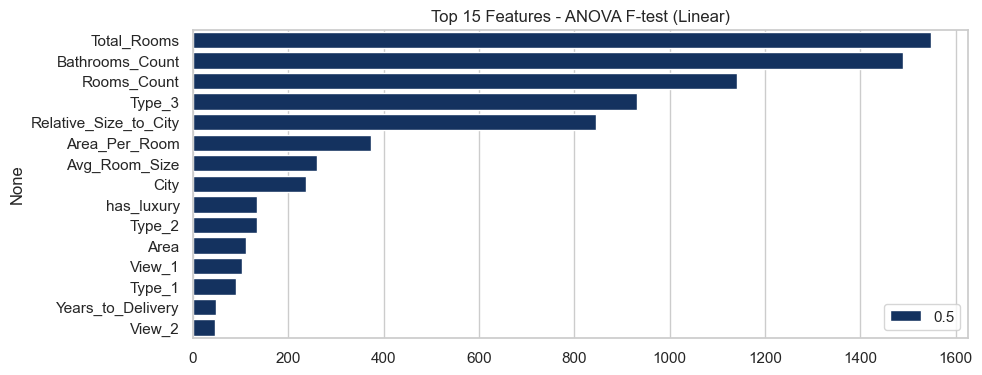

In [ ]:
print(f"1- ANOVA F-test (Linear Filter)")
anova_selector = SelectKBest(score_func=f_regression, k=optimal_k)
anova_selector.fit(X_train_processed_df, y_train)
anova_features = X_train_processed_df.columns[anova_selector.get_support()]

anova_scores = pd.Series(
    anova_selector.scores_, index=X_train_processed_df.columns
).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(
    x=anova_scores.head(optimal_k).values,
    y=anova_scores.head(optimal_k).index,
    palette="Blues_r",
    hue=0.5
)
plt.title(f"Top {optimal_k} Features - ANOVA F-test (Linear)")
plt.show()

2- Mutual Information (Non-Linear Filter)


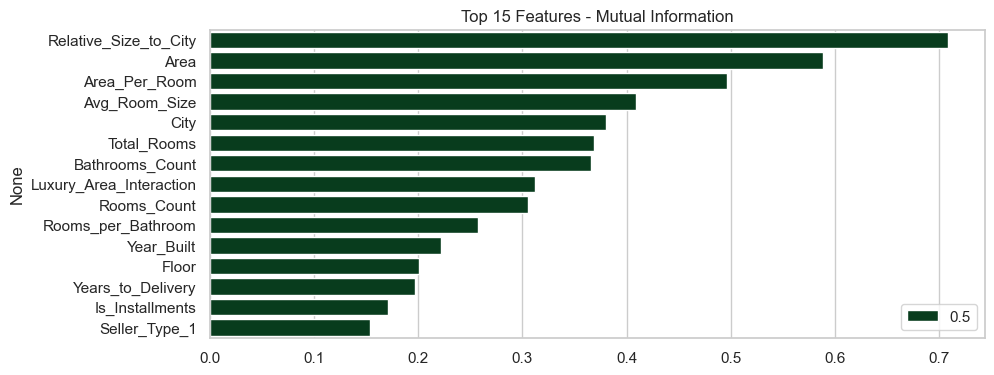

In [222]:
print(f"2- Mutual Information (Non-Linear Filter)")
mi_selector = SelectKBest(score_func=mutual_info_regression, k=optimal_k)
mi_selector.fit(X_train_processed_df, y_train)
mi_features = X_train_processed_df.columns[mi_selector.get_support()]

mi_scores = pd.Series(
    mi_selector.scores_, index=X_train_processed_df.columns
).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(
    x=mi_scores.head(optimal_k).values,
    y=mi_scores.head(optimal_k).index,
    palette="Greens_r",
    hue = 0.5
)
plt.title(f"Top {optimal_k} Features - Mutual Information")
plt.show()

3- ReliefF (Distance-based)


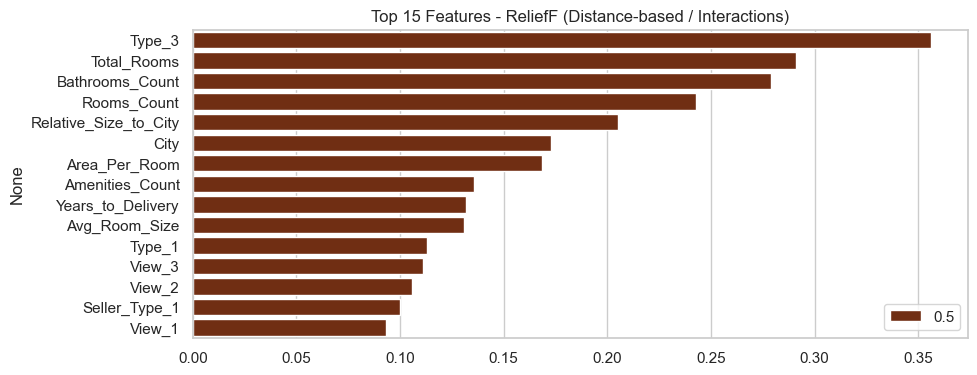

In [223]:
print("3- ReliefF (Distance-based)")
relieff = ReliefF(n_features_to_select=optimal_k, n_neighbors=20, n_jobs=-1)
relieff.fit(X_train_processed_df.values, y_train.values)
relieff_features = X_train_processed_df.columns[relieff.top_features_[:optimal_k]]

relieff_scores = pd.Series(
    relieff.feature_importances_, index=X_train_processed_df.columns
).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(
    x=relieff_scores.head(optimal_k).values,
    y=relieff_scores.head(optimal_k).index,
    palette="Oranges_r",
    hue=0.5
)
plt.title(f"Top {optimal_k} Features - ReliefF (Distance-based / Interactions)")
plt.show()

In [225]:
print(f"4- Sequential Forward Selection (Wrapper Method)")
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
sfs = SequentialFeatureSelector(
    rf, n_features_to_select=optimal_k, direction="forward", cv=3, n_jobs=-1
)
start_time = time.time()
sfs.fit(X_train_processed_df, y_train)
sfs_features = X_train_processed_df.columns[sfs.get_support()]
print(f"SFS completed in {time.time() - start_time:.2f} seconds")

4- Sequential Forward Selection (Wrapper Method)
SFS completed in 105.68 seconds


In [227]:
# --- Comparison Summary ---
print(" Feature Selection Summary")
print(f"ANOVA selected: {list(anova_features)}")
print(f"MI selected: {list(mi_features)}")
print(f"ReliefF selected: {list(relieff_features)}")
print(f"SFS selected: {list(sfs_features)}")

 Feature Selection Summary
ANOVA selected: ['Area', 'has_luxury', 'City', 'Rooms_Count', 'Bathrooms_Count', 'Years_to_Delivery', 'Total_Rooms', 'Avg_Room_Size', 'Area_Per_Room', 'Type_1', 'Type_2', 'Type_3', 'View_1', 'View_2', 'Relative_Size_to_City']
MI selected: ['Area', 'Floor', 'Year_Built', 'Is_Installments', 'City', 'Rooms_Count', 'Bathrooms_Count', 'Years_to_Delivery', 'Total_Rooms', 'Avg_Room_Size', 'Area_Per_Room', 'Rooms_per_Bathroom', 'Seller_Type_1', 'Relative_Size_to_City', 'Luxury_Area_Interaction']
ReliefF selected: ['Type_3', 'Total_Rooms', 'Bathrooms_Count', 'Rooms_Count', 'Relative_Size_to_City', 'City', 'Area_Per_Room', 'Amenities_Count', 'Years_to_Delivery', 'Avg_Room_Size', 'Type_1', 'View_3', 'View_2', 'Seller_Type_1', 'View_1']
SFS selected: ['Floor', 'Finish', 'Is_Installments', 'has_luxury', 'has_access', 'City', 'Bathrooms_Count', 'Is_Off_Plan', 'Years_to_Delivery', 'Type_1', 'Type_2', 'Type_3', 'View_0', 'Seller_Type_1', 'Relative_Size_to_City']


In [233]:
anova_set = set(anova_features)
mi_set = set(mi_features)
relieff_set = set(relieff_features)
sfs_set = set(sfs_features)

all_four_consensus = anova_set & mi_set & relieff_set & sfs_set
at_least_three = (
    (anova_set & mi_set & relieff_set)
    | (anova_set & mi_set & sfs_set)
    | (anova_set & relieff_set & sfs_set)
    | (mi_set & relieff_set & sfs_set)
)

print(
    f"Selected by ALL 4 methods (Absolute Consensus):\n{list(all_four_consensus) if all_four_consensus else 'None'}"
)
print(f"Selected by at least 3 methods:\n{list(at_least_three)}")


Selected by ALL 4 methods (Absolute Consensus):
['Years_to_Delivery', 'Relative_Size_to_City', 'Bathrooms_Count', 'City']
Selected by at least 3 methods:
['Avg_Room_Size', 'Relative_Size_to_City', 'Bathrooms_Count', 'Type_3', 'Total_Rooms', 'Rooms_Count', 'Years_to_Delivery', 'City', 'Area_Per_Room', 'Seller_Type_1', 'Type_1']


In [236]:
print("ALGORITHM-SPECIFIC UNIQUENESS (Selected by ONLY one method)")
print(f"ANOVA Unique: {list(anova_set - (mi_set | relieff_set | sfs_set))}")
print(f"Mutual Info Unique: {list(mi_set - (anova_set | relieff_set | sfs_set))}")
print(f"ReliefF Unique: {list(relieff_set - (anova_set | mi_set | sfs_set))}")
print(f"SFS Unique: {list(sfs_set - (anova_set | mi_set | relieff_set))}\n")

ALGORITHM-SPECIFIC UNIQUENESS (Selected by ONLY one method)
ANOVA Unique: []
Mutual Info Unique: ['Rooms_per_Bathroom', 'Luxury_Area_Interaction', 'Year_Built']
ReliefF Unique: ['View_3', 'Amenities_Count']
SFS Unique: ['View_0', 'has_access', 'Is_Off_Plan', 'Finish']



In [237]:
# Final data shape check
X_train_final = X_train_processed_df[sfs_features]
X_test_final = X_test_processed_df[sfs_features]
print(f"Final dataset shape after selecting top features: {X_train_final.shape}")

Final dataset shape after selecting top features: (3344, 15)


# Comprehensive Model Comparison (Benchmarking all Methods)

In [240]:
common_all = set(anova_features).intersection(
    mi_features, relieff_features, sfs_features
)

# 2 Define a dictionary of all feature sets
feature_sets = {
    "1 Baseline (All Features)": X_train_processed_df.columns,
    "2 ANOVA (Linear)": anova_features,
    "3 Mutual Info (Non-Linear)": mi_features,
    "4 ReliefF (Interactions)": relieff_features,
    "5 SFS (Wrapper Method)": sfs_features,
    "6 Golden Features (Intersection)": list(common_all),
}

results = []

In [251]:
for name, features in feature_sets.items():
    print(f"Training {name} using {len(features)} features...")

    # Subset the data for the specific feature selection method
    X_train_subset = X_train_processed_df[list(features)]
    X_test_subset = X_test_processed_df[list(features)]

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    # Measure training time
    start_time = time.time()
    rf.fit(X_train_subset, y_train)
    train_time = time.time() - start_time

    # Predictions and Evaluation
    y_pred = rf.predict(X_test_subset)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append(
        {
            "Method": name,
            "Features": len(features),
            "Training Time (s)": train_time,
            "R2 Score": r2,
            "MAE": mae,
        }
    )

Training 1 Baseline (All Features) using 32 features...
Training 2 ANOVA (Linear) using 15 features...
Training 3 Mutual Info (Non-Linear) using 15 features...
Training 4 ReliefF (Interactions) using 15 features...
Training 5 SFS (Wrapper Method) using 15 features...
Training 6 Golden Features (Intersection) using 4 features...


In [252]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                          Method  Features  Training Time (s)  R2 Score          MAE
       1 Baseline (All Features)        32               0.61      0.72 2,600,146.91
                2 ANOVA (Linear)        15               0.41      0.73 2,654,672.44
      3 Mutual Info (Non-Linear)        15               0.49      0.69 2,856,698.21
        4 ReliefF (Interactions)        15               0.40      0.72 2,594,641.34
          5 SFS (Wrapper Method)        15               0.37      0.73 2,593,155.22
6 Golden Features (Intersection)         4               0.23      0.67 2,980,475.34


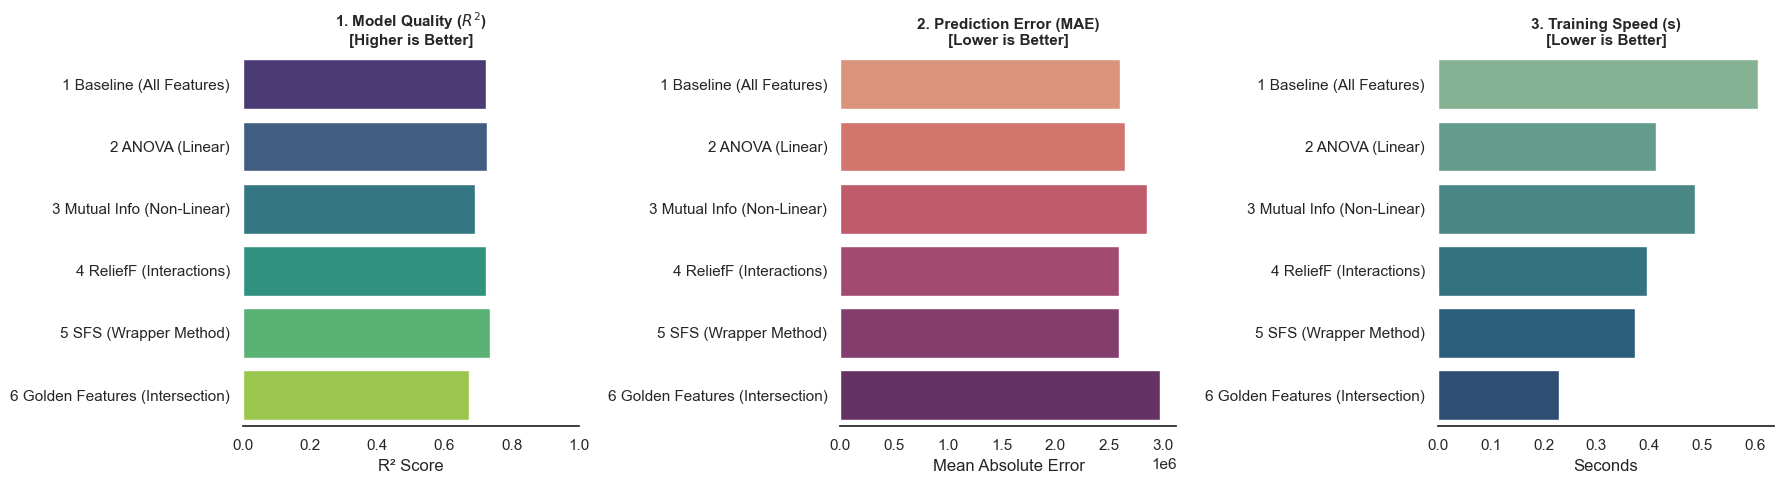

In [267]:
sns.set_theme(style="white")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Method",
    hue="Method",
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title(
    "1. Model Quality ($R^2$)\n[Higher is Better]", fontsize=11, fontweight="bold"
)
axes[0].set_xlim(0, 1.0)
axes[0].set_ylabel("")
axes[0].set_xlabel("R² Score")

sns.barplot(
    data=results_df,
    x="MAE",
    y="Method",
    hue="Method",
    palette="flare",
    legend=False,
    ax=axes[1],
)
axes[1].set_title(
    "2. Prediction Error (MAE)\n[Lower is Better]", fontsize=11, fontweight="bold"
)
axes[1].set_ylabel("")
axes[1].set_xlabel("Mean Absolute Error")

sns.barplot(
    data=results_df,
    x="Training Time (s)",
    y="Method",
    hue="Method",
    palette="crest",
    legend=False,
    ax=axes[2],
)
axes[2].set_title(
    "3. Training Speed (s)\n[Lower is Better]", fontsize=11, fontweight="bold"
)
axes[2].set_ylabel("")
axes[2].set_xlabel("Seconds")

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [268]:
best_r2 = results_df.loc[results_df['R2 Score'].idxmax()]
best_mae = results_df.loc[results_df['MAE'].idxmin()]
best_time = results_df.loc[results_df['Training Time (s)'].idxmin()]

print(f" Highest Accuracy (R² Score): {best_r2['Method']} (R² = {best_r2['R2 Score']:.4f})")
print(f" Lowest Error (MAE): {best_mae['Method']} (MAE = {best_mae['MAE']:,.2f} EGP)")
print(f" Fastest Training Time: {best_time['Method']} (Time = {best_time['Training Time (s)']:.2f} seconds)")

 Highest Accuracy (R² Score): 5 SFS (Wrapper Method) (R² = 0.7347)
 Lowest Error (MAE): 5 SFS (Wrapper Method) (MAE = 2,593,155.22 EGP)
 Fastest Training Time: 6 Golden Features (Intersection) (Time = 0.23 seconds)


# Data Imbalance Handling (Using Hybrid Approach)

In [332]:
price_bins = [0, 5_000_000, 12_000_000, float("inf")]
class_labels = ["Low", "Medium", "High"]

y_train_class = pd.cut(y_train, bins=price_bins, labels=class_labels)
y_test_class = pd.cut(y_test, bins=price_bins, labels=class_labels)

print("True Class Distribution:")
print(y_train_class.value_counts())

True Class Distribution:
Price
Low       1473
Medium    1345
High       526
Name: count, dtype: int64


In [333]:
clf_baseline = RandomForestClassifier(random_state=42)
clf_baseline.fit(X_train_processed_df, y_train_class)
y_pred_base = clf_baseline.predict(X_test_processed_df)
print(classification_report(y_test_class, y_pred_base))

              precision    recall  f1-score   support

        High       0.80      0.68      0.74       177
         Low       0.81      0.80      0.80       508
      Medium       0.68      0.73      0.70       430

    accuracy                           0.75      1115
   macro avg       0.76      0.74      0.75      1115
weighted avg       0.76      0.75      0.75      1115



In [334]:
smote = SMOTE(random_state=42)
X_res_smote, y_res_smote = smote.fit_resample(X_train_processed_df, y_train_class)

clf_smote = RandomForestClassifier(random_state=42)
clf_smote.fit(X_res_smote, y_res_smote)
y_pred_smote = clf_smote.predict(X_test_processed_df)
print(classification_report(y_test_class, y_pred_smote))

              precision    recall  f1-score   support

        High       0.77      0.76      0.76       177
         Low       0.82      0.81      0.81       508
      Medium       0.70      0.71      0.71       430

    accuracy                           0.76      1115
   macro avg       0.76      0.76      0.76      1115
weighted avg       0.76      0.76      0.76      1115



In [335]:
sme = SMOTEENN(random_state=42)
X_res_hybrid, y_res_hybrid = sme.fit_resample(X_train_processed_df, y_train_class)

clf_hybrid = RandomForestClassifier(random_state=42)
clf_hybrid.fit(X_res_hybrid, y_res_hybrid)
y_pred_hybrid = clf_hybrid.predict(X_test_processed_df)
print(classification_report(y_test_class, y_pred_hybrid))

              precision    recall  f1-score   support

        High       0.59      0.85      0.70       177
         Low       0.80      0.76      0.78       508
      Medium       0.68      0.60      0.64       430

    accuracy                           0.71      1115
   macro avg       0.69      0.74      0.71      1115
weighted avg       0.72      0.71      0.71      1115



# Data Visualization (Applying Tufte's Principles)

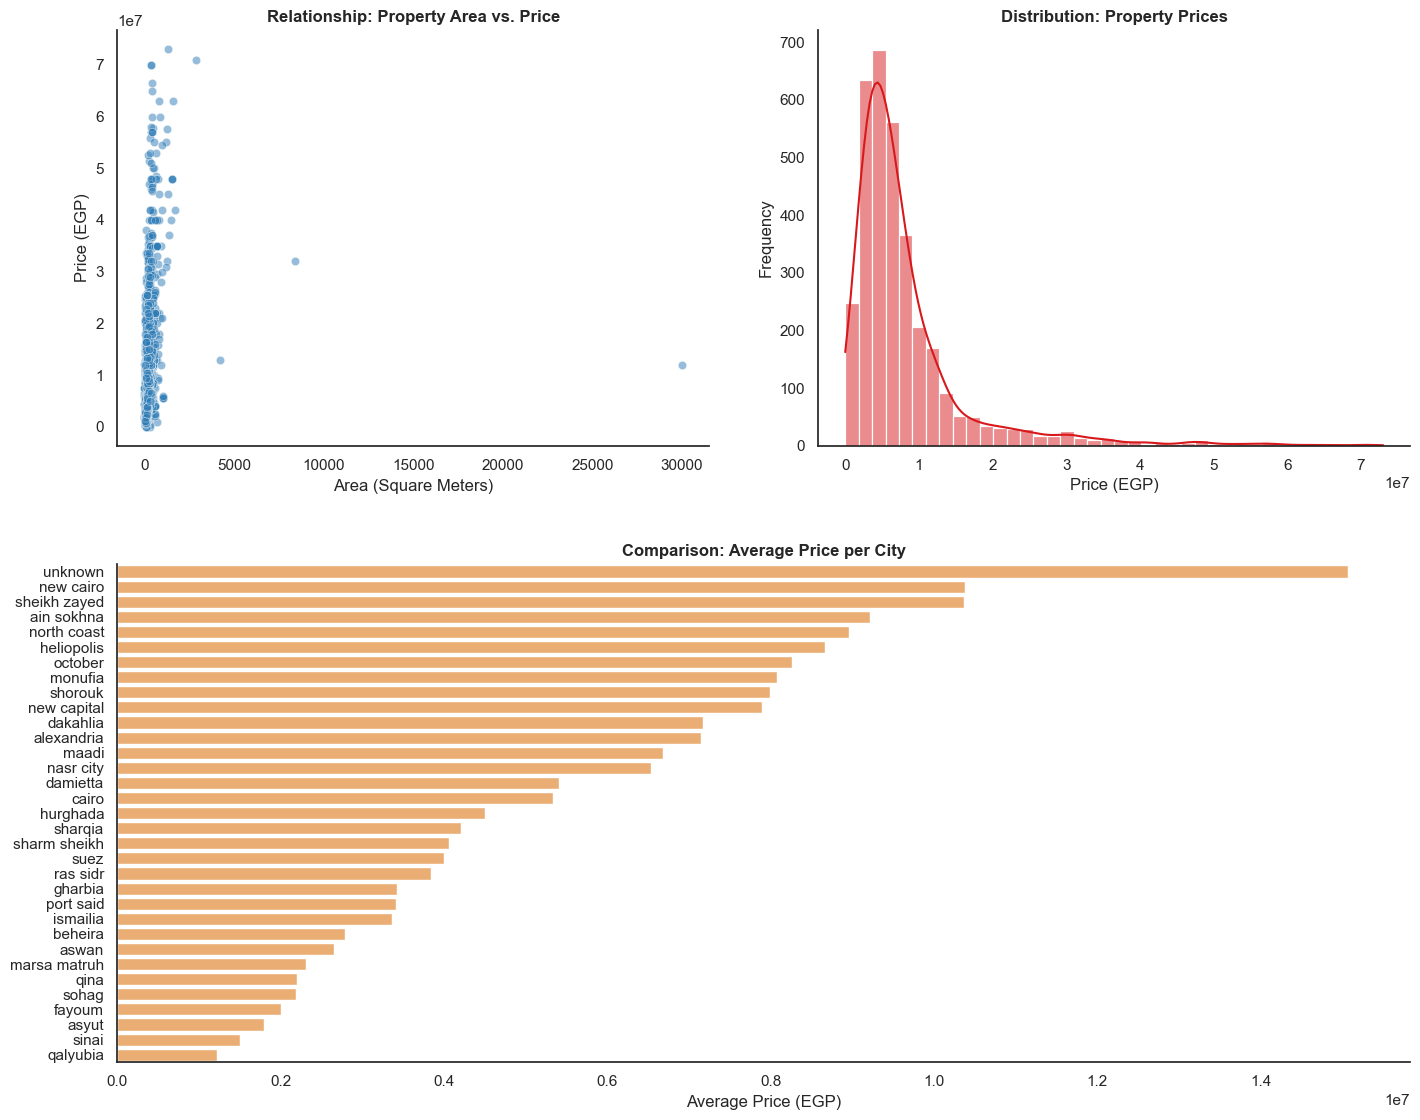

In [342]:
sns.set_theme(style="white", palette="muted")

train_viz = X_train_processed_df.copy()
train_viz["Price"] = y_train.values
train_viz["City_Name"] = df_final.loc[X_train_processed_df.index, "City"]
train_viz["Area"] = df_final.loc[
    X_train_processed_df.index, "Area"
]

fig = plt.figure(figsize=(15, 12))
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax0 = fig.add_subplot(grid[0, 0])
ax1 = fig.add_subplot(grid[0, 1])
ax2 = fig.add_subplot(grid[1, :])

sns.scatterplot(data=train_viz, x="Area", y="Price", alpha=0.5, color="#2c7bb6", ax=ax0)
ax0.set_title("Relationship: Property Area vs. Price", fontsize=12, fontweight="bold")
ax0.set_xlabel("Area (Square Meters)")
ax0.set_ylabel("Price (EGP)")
sns.despine(ax=ax0)

sns.histplot(data=train_viz, x="Price", bins=40, color="#d7191c", kde=True, ax=ax1)
ax1.set_title("Distribution: Property Prices", fontsize=12, fontweight="bold")
ax1.set_xlabel("Price (EGP)")
ax1.set_ylabel("Frequency")
sns.despine(ax=ax1)

city_order = (
    train_viz.groupby("City_Name")["Price"].mean().sort_values(ascending=False).index
)
sns.barplot(
    data=train_viz,
    y="City_Name",
    x="Price",
    order=city_order,
    errorbar=None,
    color="#fdae61",
    ax=ax2,
)
ax2.set_title("Comparison: Average Price per City", fontsize=12, fontweight="bold")
ax2.set_xlabel("Average Price (EGP)")
ax2.set_ylabel("")
sns.despine(ax=ax2)

plt.tight_layout(pad=3.0)
plt.show()

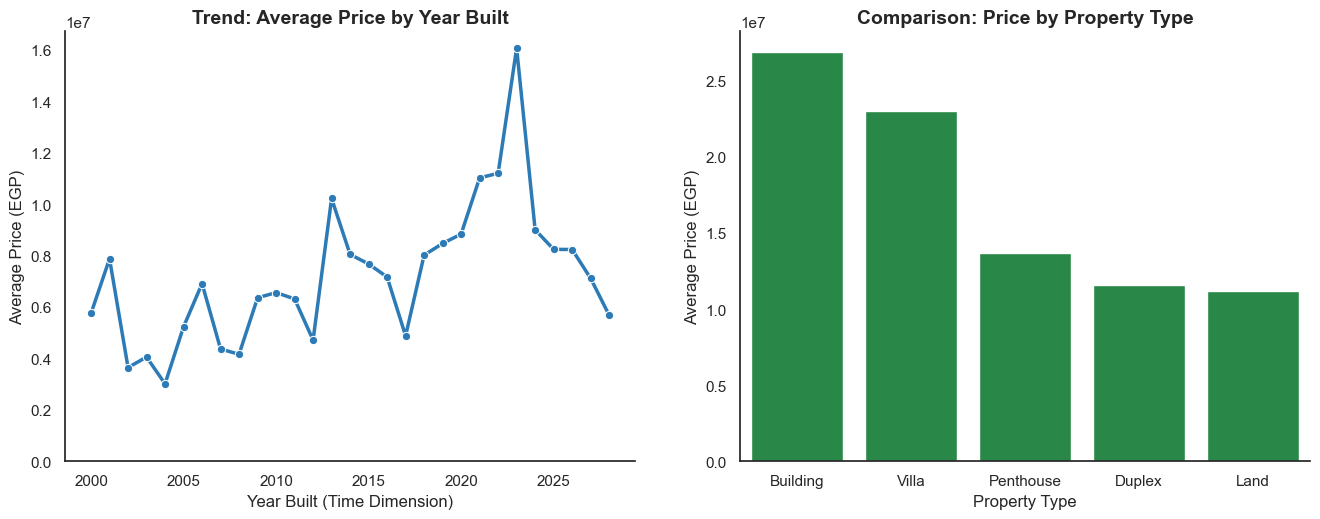

In [341]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

train_viz['Year_Built'] = df_final.loc[X_train_processed_df.index, 'Year_Built']
train_viz['Property_Type'] = df_final.loc[X_train_processed_df.index, 'Type']

trend_data = train_viz[(train_viz['Year_Built'] >= 2000) & (train_viz['Year_Built'] <= 2028)]
yearly_price = trend_data.groupby('Year_Built')['Price'].mean().reset_index()

sns.lineplot(data=yearly_price, x='Year_Built', y='Price', marker='o', color='#2c7bb6', linewidth=2.5, ax=axes2[0])
axes2[0].set_title('Trend: Average Price by Year Built', fontsize=14, fontweight='bold')
axes2[0].set_xlabel('Year Built (Time Dimension)')
axes2[0].set_ylabel('Average Price (EGP)')
axes2[0].set_ylim(bottom=0)
sns.despine(ax=axes2[0])

type_price = train_viz.groupby('Property_Type')['Price'].mean().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data=type_price, x='Property_Type', y='Price', color='#1a9641', ax=axes2[1])
axes2[1].set_title('Comparison: Price by Property Type', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Property Type')
axes2[1].set_ylabel('Average Price (EGP)')
axes2[1].set_ylim(bottom=0)
sns.despine(ax=axes2[1])

plt.tight_layout(pad=3.0)
plt.show()